In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from torch import nn
import torch.nn.functional as F
from scipy.stats import linregress
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import json

In [2]:
def moving_average(data, window_size=15):
    X_smooth = np.zeros(data.shape)
    for i,channel in enumerate(data):
        X_smooth[i] = np.convolve(channel, np.ones(window_size)/window_size, mode='same')
    return torch.from_numpy(X_smooth).to(torch.float32)
def warp_time(data, label, max_scale=1.5):
    data = data.numpy()

    L = data.shape[1]
    scale = np.random.uniform(1, max_scale)
    new_L = int(L * scale)
    orig_t = np.linspace(0, 1, L)
    new_t = np.linspace(0, 1, new_L)

    warped = np.zeros((data.shape[0], new_L))
    for i, channel in enumerate(data):
        warped[i] = np.interp(new_t, orig_t, channel)
    
    # label = torch.from_numpy(np.interp(new_t, orig_t, label)).to(torch.float32)
    # label = label * scale

    # randomly crop to original length
    if new_L > L:
        start_idx = np.random.randint(0, new_L - L)
        warped = warped[:, start_idx:start_idx + L]
        # label = label[start_idx:start_idx + L]
        # label = label - (start_idx / L)

    return torch.from_numpy(warped).to(torch.float32), label

def scale(data, low=0.6, high=1.4):
    return data*np.random.uniform(low, high)

def segment_y(y, t=40):
    end_rep_markers = torch.where(torch.diff(y) < 0)[0]
    y = torch.zeros_like(y)
    starts = (end_rep_markers - t).clamp(0)
    ends = (end_rep_markers + t).clamp(0, y.shape[0])
    for start,end in zip(starts, ends):
        y[start: end] = 1
    return y
class IMUDataset(Dataset):
    def __init__(self, df, winsize, stride, full_winsize, n_LSTM_windows, LSTM_stride, transform=None, aug=False, extra_pad=False):
        self.X = torch.from_numpy(df[['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values)
        self.y = torch.from_numpy(df['rir'].values).to(torch.float32)
        if transform is not None:
            self.X = transform(self.X)
        self.X = self.X.transpose(0, 1).to(torch.float32)
        self.winsize = winsize
        self.stride = stride
        self.full_winsize = full_winsize
        self.n_LSTM_windows = n_LSTM_windows
        self.LSTM_stride = LSTM_stride
        self.aug = aug


        self.len = (self.X.shape[1] - full_winsize) // stride + 1

        # pad to get at least one window
        if self.len <= 0:
            pad = full_winsize - self.X.shape[1]
            self.X = torch.cat([self.X, torch.zeros(self.X.shape[0], pad)], dim=1)
            self.y = torch.cat([self.y, torch.zeros(pad)])

        if extra_pad:
            # pad by winsize // 2 to get more windows
            pad = (winsize // 2) * stride
            self.X = torch.cat([self.X, torch.zeros(self.X.shape[0], pad)], dim=1)
            self.y = torch.cat([self.y, torch.zeros(pad)])
        
        self.len = (self.X.shape[1] - full_winsize) // stride + 1

    def __len__(self):
        return self.len
    def __getitem__(self, i):
        if i >= self.len:
            raise IndexError
        start = i * self.stride
        end = start + self.full_winsize

        X = self.X[:, start:end]
        y = self.y[start:end]

        X = moving_average(X)
        if self.aug:
            X,y = warp_time(X,y)
            X = scale(X)
        
        # window by LSTM stride
        X = X.unfold(1, self.winsize, self.LSTM_stride).permute(1,0,2)
        y = y.unfold(0, self.winsize, self.LSTM_stride)

        # FOR REGRESSION: y = y.mean() (single value)
        # y = y.mean()

        # FOR BINARY: 1 if y is last rep (< 0.5), 0 if not (single value)
        # y = torch.Tensor([1.0 if y.mean() < 0.5 else 0.0])
        y = (y.mean(dim=1) < 2.5).float().unsqueeze(1)

        # FOR SEGMENTATION: if y changes during window, y = 1 at that point. everywhere else is 0 (<winsize> values)
        # y = segment_y(y)

        # FOR SEGMENTATION REGRESSION: y = time when y changes (single value)
        # diff = torch.diff(y)
        # y = torch.diff(y).argmin().unsqueeze(0) / self.winsize if diff.min() < 0 else torch.Tensor([-1])
        
        return X, y

In [3]:
HZ = 100
in_channels = 6
df = pd.read_csv('../data/data.csv')
session_ids = df['session_id'].unique()
print(len(session_ids))
train_ids, val_ids = train_test_split(session_ids, test_size=0.2, random_state=42)
train_ids = np.array([train_id for train_id in train_ids if df[df.session_id == train_id].failure.sum()])
val_ids = np.array([val_id for val_id in val_ids if df[df.session_id == val_id].failure.sum()])

df[['acc_x', 'acc_y', 'acc_z']] = (df[['acc_x', 'acc_y', 'acc_z']] / 2.0).clip(-1, 1)           # normalize accelerometer data from [-2g, 2g] to [-1, 1]
df[['gyr_x', 'gyr_y', 'gyr_z']] = (df[['gyr_x', 'gyr_y', 'gyr_z']] / 250.0).clip(-1, 1)         # normalize gyroscope data from [-250dps, 250dps] to [-1, 1]

# winsize_t = 5 # seconds
# stride_t = 0.01 # seconds
# winsize = int(winsize_t * HZ)
# stride = int(stride_t * HZ)
winsize = 256
stride = 2

n_LSTM_windows = 32
LSTM_stride = 64
print(winsize, stride)

full_winsize = LSTM_stride * (n_LSTM_windows-1) + winsize
print(full_winsize)

train = df.loc[df['session_id'].isin(train_ids), ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values
# norm = torch.from_numpy(train.mean(axis=0)), torch.from_numpy(train.std(axis=0))

# def transform(x):
    # return (x - norm[0]) / norm[1]
transform = None

train_dataset = ConcatDataset([IMUDataset(
    df[df['session_id'] == session_id], 
    winsize, stride,
    full_winsize, n_LSTM_windows, LSTM_stride,
    transform, aug=True, extra_pad=True
) for session_id in train_ids])
val_dataset = ConcatDataset([IMUDataset(
    df[df['session_id'] == session_id], 
    winsize, stride, 
    full_winsize, n_LSTM_windows, LSTM_stride,
    transform, aug=False, extra_pad=True
) for session_id in val_ids])

len(train_dataset), len(val_dataset)

72
256 2
2240


(43480, 12107)

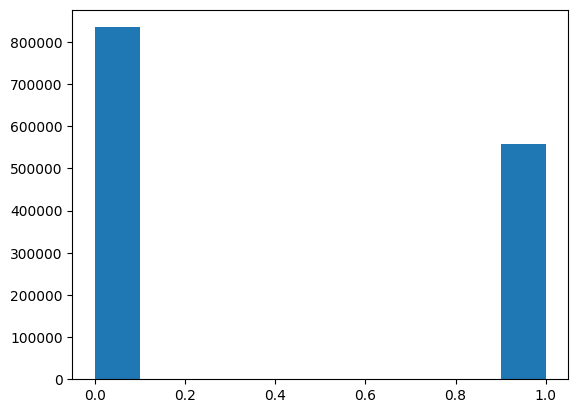

In [5]:
# windows = []
window_labels = []
for X, y in train_dataset:
    # windows.append(X.T.numpy())
    window_labels.append(y)
window_labels = np.concatenate(window_labels)
plt.hist(window_labels);

In [ ]:
(window_labels == 0).sum() / (window_labels == 1).sum()

np.float64(18.850370899282)

In [6]:
len(val_dataset.datasets[1])

428

Text(0.5, 0.98, '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.\n 1. 1. 1. 1. 1. 1. 1. 1.]')

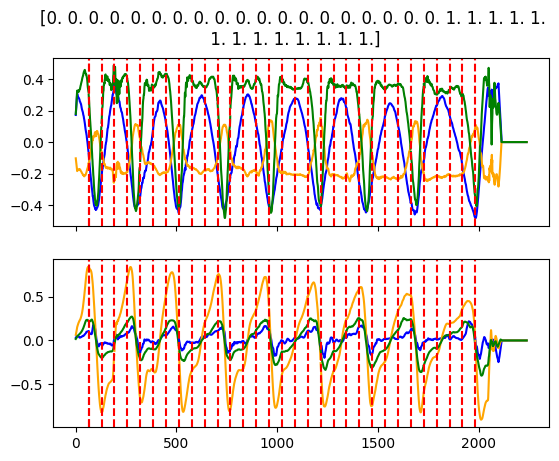

In [7]:
# X,y = train_dataset[500]
X,y = val_dataset.datasets[0][0]

fig, axes = plt.subplots(2,1, sharex=True)

axes[0].plot(X[0, 0, :LSTM_stride], color='blue')
axes[0].plot(X[0, 1, :LSTM_stride], color='orange')
axes[0].plot(X[0, 2, :LSTM_stride], color='green')
axes[1].plot(X[0, 3, :LSTM_stride], color='blue')
axes[1].plot(X[0, 4, :LSTM_stride], color='orange')
axes[1].plot(X[0, 5, :LSTM_stride], color='green')
axes[0].axvline(LSTM_stride, color='red', linestyle='--')
axes[1].axvline(LSTM_stride, color='red', linestyle='--')

for i in range(1, n_LSTM_windows):
    upper = LSTM_stride if i < n_LSTM_windows - 1 else None
    range_upper = (i+1)*LSTM_stride if upper is not None else i*LSTM_stride + winsize
    axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 0, :upper], color='blue')
    axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 1, :upper], color='orange')
    axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 2, :upper], color='green')
    axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 3, :upper], color='blue')
    axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 4, :upper], color='orange')
    axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 5, :upper], color='green')
    axes[0].axvline(i*LSTM_stride, color='red', linestyle='--')
    axes[1].axvline(i*LSTM_stride, color='red', linestyle='--')

plt.suptitle(y[:,0].numpy())

In [4]:
def get_time_in_reps(preds, stride, winsize):
    # preds: N x T x C
    time_in_rep = []
    # consolidated = []
    end_reps = []
    for pred in preds: # each element in batch
        consolidatedi = []
        for i,predi in enumerate(pred): # each element in time
            upper = stride if i < len(pred) - 1 else len(predi)
            consolidatedi.append(predi[:upper])
        consolidatedi = torch.cat(consolidatedi, axis=0)
        consolidatedi = torch.from_numpy(np.convolve(consolidatedi, np.ones(100)/100, mode='same').round()).to(torch.float32)

        time_in_repi = torch.zeros_like(consolidatedi).to(torch.float32)
        end_repsi = []
        if consolidatedi.sum() > 0:
            diff = np.diff(consolidatedi)
            starts = np.where(diff > 0)[0]
            ends = np.where(diff < 0)[0]
            if len(starts) == 0 or len(ends) == 0:
                if len(starts) == 0:
                    # len(end) == 1 -> start is the beginning of session
                    starts = np.array([0])
                elif len(ends) == 0:
                    # len(start) == 1 -> end is the end of session
                    ends = np.array([len(pred[0])])
            else:
                if starts[0] > ends[0]:
                    # first end has no start -> first start is the beginning of session
                    starts = np.concatenate([[0], starts])
                if ends[-1] < starts[-1]:
                    # last start has no end -> last end is the end of session
                    ends = np.concatenate([ends, [len(pred[0])]])
            for start,end in zip(starts, ends):
                end_repsi.append((start + end) // 2)
            
            for i in range(1, len(end_repsi)):
                time_in_repi[end_repsi[i-1]:end_repsi[i]] = (end_repsi[i] - end_repsi[i-1]) / full_winsize
                # time_in_rep.append(end_repsi[i] - end_repsi[i-1])

        end_reps.append(end_repsi)
        # consolidated.append(consolidatedi)
        time_in_rep.append(time_in_repi)
    # preds = torch.stack(consolidated, axis=0)
    time_in_rep = torch.stack(time_in_rep, axis=0)

    # rewindow
    time_in_rep = time_in_rep.unfold(1, winsize, stride)

    return time_in_rep

class ResBlock(nn.Module):
    # One layer of convolutional block with batchnorm, relu and dropout
    def __init__(
            self, in_channels, out_channels,
            kernel_size=3, stride=1, dropout=0.0,
        ):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(
                in_channels, out_channels, 
                kernel_size=kernel_size, stride=stride, padding=kernel_size // 2,
            ),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.skip = nn.Conv1d(
            in_channels, out_channels, kernel_size=1, stride=stride
        ) if in_channels != out_channels or stride > 1 else nn.Identity()
    def forward(self, x):
        return self.block(x) + self.skip(x)
    
class DepthBlock(nn.Module):
    # "depth" number of ConvBlocks with downsample on the first block
    def __init__(
            self, depth, in_channels, out_channels,
            kernel_size=3, downsample_stride=2, 
            dropout=0.0
    ):
        super().__init__()
        self.blocks = nn.Sequential(*[
            ResBlock(
                in_channels=in_channels if i == 0 else out_channels, 
                out_channels=out_channels,
                kernel_size=kernel_size, 
                stride=downsample_stride if i == 0 else 1,
                dropout=dropout
            )
            for i in range(depth)
        ])
    def forward(self, x):
        return self.blocks(x)
 
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.width = config['width']
        self.depth = config['depth']
        self.stem_out_c = config['stem_out_c']
        self.stem_kernel = config['stem_kernel']
        self.dropout = config['dropout']

        if len(self.width) != len(self.depth):
            raise ValueError('Width and depth must have the same length')
        self.conv_out_channels = self.stem_out_c if len(self.width) == 0 else self.width[-1]

        self.encoder = nn.Sequential(
            # nn.Conv1d(in_channels, self.stem_out_c, kernel_size=self.stem_kernel, padding=self.stem_kernel // 2, stride=2),
            # nn.BatchNorm1d(self.stem_out_c),
            # nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
            ResBlock(in_channels, self.stem_out_c, kernel_size=self.stem_kernel, stride=2),
            *[DepthBlock(
                depth=self.depth[i],
                in_channels=self.stem_out_c if i == 0 else self.width[i-1], 
                out_channels=self.width[i],
                dropout=self.dropout, 
            ) for i in range(len(self.width))]
        )
    def forward(self, x):
        return self.encoder(x)

class ConvNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        self.encoder = Encoder(config)
        self.ap = nn.AdaptiveAvgPool1d(1)
        # self.fc = nn.Linear(512, winsize // 2)
        self.fc = nn.Linear(self.encoder.conv_out_channels, winsize)
    def forward(self, x):
        emb = self.encoder(x)
        # x = self.conv(x)
        x = self.ap(emb).squeeze(-1)
        seg_logits = self.fc(x)
        # x = torch.repeat_interleave(x, 2, dim=1)
        return emb, seg_logits
    
    def freeze(self, stop_idx=None):
        if stop_idx is None:
            stop_idx = len(self.encoder.encoder)
        for block in self.encoder.encoder[:stop_idx]:
            for param in block.parameters():
                param.requires_grad = False
        for param in self.fc.parameters():
            param.requires_grad = False

class LSTMNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        in_channels = 6


        self.encoder = ConvNet(config)
        hidden_size = config['lstm_config']['hidden_size']
        # encoder_proj_channels = config['lstm_config']['encoder_proj_channels']
        skip_channels = config['lstm_config']['skip_channels']
        num_layers = config['lstm_config']['num_layers']
        dropout = config['lstm_config']['dropout']
        linear_hidden_size = config['lstm_config']['linear_hidden_size']

        # # Project encoder output to hidden size
        # self.conv_proj = nn.Conv1d(
        #     self.encoder.encoder.conv_out_channels, 
        #     encoder_proj_channels, 
        #     kernel_size=1
        # )

        # Convolution layer from input signal to skip_channels size
        self.conv_skip = nn.Sequential(
            nn.Conv1d(in_channels, skip_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(skip_channels),
            nn.ReLU(),
            # ResBlock(in_channels, skip_channels, kernel_size=7, stride=1),
        )
        self.ap = nn.AdaptiveAvgPool1d(1)

        # Project encoder, skip layer, and time_in_reps to lstm input size
        self.lstm_proj = nn.Linear(
            # encoder_proj_channels + skip_channels + winsize,
            self.encoder.encoder.conv_out_channels + skip_channels + winsize,
            hidden_size
        )

        # LSTM layer on projected encoder, skip layer, and time_in_reps
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
            num_layers=num_layers,
            dropout=dropout
        )

        # Linear layer to predict the output
        if linear_hidden_size == 0:
            self.fc = nn.Linear(hidden_size, 1)
        else:
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, linear_hidden_size),
                nn.ReLU(),
                nn.Linear(linear_hidden_size, 1)
            )
    def forward(self, x):
        N, T, C, L = x.shape

        x = x.view(N*T, C, L)
        
        # Run encoder to get embeddings and segmentation logits
        x_seg, seg_logits = self.encoder(x)

        # x_seg = self.conv_proj(x_seg)
        x_seg = self.ap(x_seg).squeeze(-1)
        x_seg = x_seg.view(N, T, -1)

        # Project segmentation logits to seg_proj_size
        seg_logits = F.sigmoid(seg_logits).round()
        time_in_rep = get_time_in_reps(seg_logits.view(N, T, L).detach().cpu(), LSTM_stride, winsize).to(x.device)

        x_skip = self.conv_skip(x)
        x_skip = self.ap(x_skip).squeeze(-1)
        x_skip = x_skip.view(N, T, -1)

        x = torch.cat([x_seg, x_skip, time_in_rep], dim=2)
        x = self.lstm_proj(x)

        o, (h,c) = self.lstm(x)
        # x = self.fc(o[:, -1, :]) # predict for last time step
        x = self.fc(o)        # predict for all time steps
        return x
    
    def get_optimizer(self, lr, weight_decay=1e-4, betas=(0.9, 0.999)):
        # AdamW optimzer - apply weight decay to linear and conv weights
        # but not to biases and batchnorm layers
        params = self.named_parameters()
        decay_params = [p for n,p in params if p.dim() >= 2]
        no_decay_params = [p for n,p in params if p.dim() < 2]
        optimizer = torch.optim.AdamW([
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': no_decay_params, 'weight_decay': 0.0}
        ], betas=betas, lr=lr)
        return optimizer

class Loss(nn.Module):
    def __init__(self, device, pos_weight):
        super().__init__()
        self.loss = nn.BCEWithLogitsLoss(pos_weight=torch.Tensor([pos_weight]).to(device))
        # self.loss = nn.BCEWithLogitsLoss()
        # self.loss = nn.MSELoss()
    def forward(self, y_pred, y_true):
        return self.loss(y_pred, y_true)
        # return self.loss(y_pred, y_true[:,-1])

In [5]:
# lstm_config = {
#     'num_layers': 4,
#     'skip_channels': 256,
#     'hidden_size': 768,
#     'dropout': 0.1,
#     'linear_hidden_size': 0,
#     'freeze': True,
#     'num_windows': n_LSTM_windows,
# }

In [15]:
# lstm_config = torch.load('../best_model-lstm-83t_32-timerep.pth')[1]['lstm_config']
# lstm_config['pos_weight'] =  1.3
lstm_config = torch.load('../best_model-lstm-83t_32-timerep.pth')[1]['lstm_config']
lstm_config['pos_weight'] =  1.3
lstm_config['learning_rate'] = 3e-3
lstm_config['weight_decay'] = 1e-4

In [16]:
config = json.load(open('../logs/search256-3/56/config.json'))
weights = torch.load('../logs/search256-3/56/best_model.pth')
# lstm_config = config['lstm_config']
config['lstm_config'] = lstm_config
# config['dropout'] = 0 # no dropout in encoder

trainloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=128, shuffle=False)
device = 'cuda:1'

model = LSTMNet(config).to(device)
model.encoder.load_state_dict(weights)
model.encoder.freeze()

criterion = Loss(device, lstm_config['pos_weight'])
optimizer = model.get_optimizer(lr=lstm_config['learning_rate'], weight_decay=lstm_config['weight_decay'])

print(sum(p.numel() for p in model.encoder.parameters()))
print(sum(p.numel() for p in model.parameters() if p.requires_grad))
model.eval();

2971648
19692289


In [17]:
X,y = next(iter(trainloader))
ypred = model(X.to(device))
ypred.shape

torch.Size([128, 32, 1])

In [80]:
# def get_time_in_reps(preds, stride, winsize):
#     # preds: N x T x C
#     time_in_rep = []
#     # consolidated = []
#     end_reps = []
#     for pred in preds: # each element in batch
#         consolidatedi = []
#         for i,predi in enumerate(pred): # each element in time
#             print(predi.shape)
#             upper = stride if i < len(pred) - 1 else len(predi)
#             print(upper)
#             consolidatedi.append(predi[:upper])
#             print(len(consolidatedi), consolidatedi[-1].shape)
#             predi = torch.cat([*consolidatedi, predi[upper:]])
#             print(predi.shape)
#             time_in_rep.append(predi[-winsize:].unsqueeze(0))
#             print(time_in_rep[-1].shape)
#         break


#     #     consolidatedi = torch.cat(consolidatedi, axis=0)
#     #     consolidatedi = torch.from_numpy(np.convolve(consolidatedi, np.ones(100)/100, mode='same').round()).to(torch.float32)

#     #     time_in_repi = torch.zeros_like(consolidatedi).to(torch.float32)
#     #     end_repsi = []
#     #     if consolidatedi.sum() > 0:
#     #         diff = np.diff(consolidatedi)
#     #         starts = np.where(diff > 0)[0]
#     #         ends = np.where(diff < 0)[0]
#     #         if len(starts) == 0 or len(ends) == 0:
#     #             if len(starts) == 0:
#     #                 # len(end) == 1 -> start is the beginning of session
#     #                 starts = np.array([0])
#     #             elif len(ends) == 0:
#     #                 # len(start) == 1 -> end is the end of session
#     #                 ends = np.array([len(pred[0])])
#     #         else:
#     #             if starts[0] > ends[0]:
#     #                 # first end has no start -> first start is the beginning of session
#     #                 starts = np.concatenate([[0], starts])
#     #             if ends[-1] < starts[-1]:
#     #                 # last start has no end -> last end is the end of session
#     #                 ends = np.concatenate([ends, [len(pred[0])]])
#     #         for start,end in zip(starts, ends):
#     #             end_repsi.append((start + end) // 2)
            
#     #         for i in range(1, len(end_repsi)):
#     #             time_in_repi[end_repsi[i-1]:end_repsi[i]] = (end_repsi[i] - end_repsi[i-1]) / full_winsize
#     #             # time_in_rep.append(end_repsi[i] - end_repsi[i-1])

#     #     end_reps.append(end_repsi)
#     #     # consolidated.append(consolidatedi)
#     #     time_in_rep.append(time_in_repi)
#     # # preds = torch.stack(consolidated, axis=0)
#     # time_in_rep = torch.stack(time_in_rep, axis=0)

#     # rewindow
#     # time_in_rep = time_in_rep.unfold(1, winsize, stride)

#     return torch.cat(time_in_rep)

# X,y = next(iter(trainloader))
# with torch.no_grad():
#     N,T,C,L = X.shape
#     x_seg, seg_logits = model.encoder(X.to(device).view(N*T, C, L))
#     seg_logits = F.sigmoid(seg_logits).round()
# seg_logits = seg_logits.cpu()
# time_in_rep = get_time_in_reps(seg_logits.view(N, T, L).detach().cpu(), LSTM_stride, winsize)#.to(device)
# seg_logits = seg_logits.view(N, T, L)
# time_in_rep

In [81]:
# # X,y = next(iter(trainloader))
# # with torch.no_grad():
# #     N,T,C,L = X.shape
# #     x_seg, seg_logits = model.encoder(X.to(device).view(N*T, C, L))
# #     seg_logits = F.sigmoid(seg_logits).round()
# #     time_in_rep = get_time_in_reps(seg_logits.view(N, T, L).detach().cpu(), LSTM_stride, winsize).to(device)
# #     seg_logits = seg_logits.view(N, T, L)

# # X =X[0]
# # y=y[0]
# # # time_in_rep = time_in_rep[0].cpu()
# # seg_logits = seg_logits[0].cpu()

# fig, axes = plt.subplots(3,1, sharex=True)

# axes[0].plot(X[0, 0, :LSTM_stride], color='blue')
# axes[0].plot(X[0, 1, :LSTM_stride], color='orange')
# axes[0].plot(X[0, 2, :LSTM_stride], color='green')
# axes[1].plot(X[0, 3, :LSTM_stride], color='blue')
# axes[1].plot(X[0, 4, :LSTM_stride], color='orange')
# axes[1].plot(X[0, 5, :LSTM_stride], color='green')
# axes[2].plot(time_in_rep[0, :LSTM_stride], color='blue')
# # axes[2].plot(seg_logits[0, :LSTM_stride], color='red')
# axes[0].axvline(LSTM_stride, color='red', linestyle='--')
# axes[1].axvline(LSTM_stride, color='red', linestyle='--')
# # axes[2].axvline(LSTM_stride, color='red', linestyle='--')

# for i in range(1, n_LSTM_windows):
#     upper = LSTM_stride if i < n_LSTM_windows - 1 else None
#     range_upper = (i+1)*LSTM_stride if upper is not None else i*LSTM_stride + winsize
#     axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 0, :upper], color='blue')
#     axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 1, :upper], color='orange')
#     axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 2, :upper], color='green')
#     axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 3, :upper], color='blue')
#     axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 4, :upper], color='orange')
#     axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 5, :upper], color='green')
#     axes[2].plot(np.arange(i*LSTM_stride, range_upper), time_in_rep[i, :upper], color='blue')
#     # axes[2].plot(np.arange(i*LSTM_stride, range_upper), seg_logits[i, :upper], color='red')
#     axes[0].axvline(i*LSTM_stride, color='red', linestyle='--')
#     axes[1].axvline(i*LSTM_stride, color='red', linestyle='--')
#     # axes[2].axvline(i*LSTM_stride, color='red', linestyle='--')

# print(y[:,0])

In [18]:
def train(epochs, model, trainloader, valloader, criterion, optimizer, outfile='best_model.pth'):
    train_losses = []
    val_losses = []
    best_val_f1 = float(0)
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X, y in trainloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            ypred = model(X)
            loss = criterion(ypred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_losses.append(train_loss / len(trainloader))
        model.eval()
        val_loss = 0
        ypreds = []
        ys = []
        with torch.no_grad():
            for X, y in valloader:
                X, y = X.to(device), y.to(device)
                ypred = model(X)
                loss = criterion(ypred, y)
                val_loss += loss.item()
                ypreds.append(F.sigmoid(ypred.cpu()).round())
                # ys.append(y.cpu())
                ys.append(y.cpu())
                # ys.append(y[:,-1].cpu())
        val_losses.append(val_loss / len(valloader))
        ypreds = torch.cat(ypreds).numpy().flatten()
        ys = torch.cat(ys).numpy().flatten()
        precision, recall, f1, _ = precision_recall_fscore_support(ys, ypreds, average='binary')
        if f1 > best_val_f1:
            best_val_f1 = f1
            torch.save((model.state_dict(),model.config), outfile)
            print(f'*Epoch {epoch} train loss: {train_losses[-1]}, val loss: {val_losses[-1]}, prec: {precision:.04f}, recall: {recall:.04f}, f1: {f1:.04f}*')
        else:
            print(f'Epoch {epoch} train loss: {train_losses[-1]}, val loss: {val_losses[-1]}, prec: {precision:.04f}, recall: {recall:.04f}, f1: {f1:.04f}')
        torch.save((model.state_dict(),model.config), f'model.pth')
        plt.plot(train_losses, label='Train')
        plt.plot(val_losses, label='Val')
        plt.legend()
        plt.savefig('loss.png')
        plt.close()
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.legend()
    plt.show()
    return train_losses, val_losses

In [19]:
def evaluate(model, valloader, trainloader):
    model.eval()
    # train_loss = 0
    # train_iou = 0
    # with torch.no_grad():
    #     for X, y in trainloader:
    #         X, y = X.to(device), y.to(device)
    #         ypred = model(X)
    #         loss = criterion(ypred, y)
    #         train_loss += loss.item()
    #         train_iou += iou_metric(F.sigmoid(ypred).round(), y).item()
    # train_loss /= len(trainloader)
    # train_iou /= len(trainloader)
    # print(f'Train Loss: {train_loss:.07f}\tTrain IOU: {train_iou:.07f}')

    val_loss = 0
    ypreds = []
    ys = []
    confs = []
    with torch.no_grad():
        for X, y in valloader:
            X, y = X.to(device), y.to(device)
            ypred = model(X)
            loss = criterion(ypred, y)
            val_loss += loss.item()
            ypred = F.sigmoid(ypred)

            # y, ypred = y[:,-1:], ypred[:,-1:] # only last time step
            confs.append(ypred.cpu())
            ypred = ypred.round()
            ypreds.append(ypred.cpu())
            ys.append(y.cpu())
    ypreds = torch.cat(ypreds).numpy().flatten()
    ys = torch.cat(ys).numpy().flatten()
    confs = torch.cat(confs).numpy().flatten()

    val_loss /= len(valloader)
    print(f'Val Loss: {val_loss:.07f}')

    cm = confusion_matrix(ys, ypreds)
    tn, fp, fn, tp = cm.flatten()
    total = tn + fp + fn + tp

    labels = np.array([
        [f"{tn}\n{tn/total:.1%}", f"{fp}\n{fp/total:.1%}"],
        [f"{fn}\n{fn/total:.1%}", f"{tp}\n{tp/total:.1%}"]
    ])

    precision, recall, f1, _ = precision_recall_fscore_support(ys, ypreds, average='binary')
    accuracy = (ypreds == ys).sum() / len(ys)
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Accuracy: {accuracy:.4f}")

    fig, axes = plt.subplots(1,2,figsize=(10, 5))
    sns.heatmap(cm, annot=labels, fmt='', xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"], ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'Confusion Matrix F1: {f1:.4f}')

    fpr, tpr, thresholds = roc_curve(ys, confs)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")

    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal (random classifier)

    # Formatting
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC')
    axes[1].legend(loc="lower right")

    plt.show()

In [ ]:
# TODO contrastive learning with RiR labels (positive pairs are failure reps)
train_losses, val_losses = train(40, model, trainloader, valloader, criterion, optimizer, outfile='../best_model-3binary.pth')

Val Loss: 0.5905099
Precision: 0.8092, Recall: 0.7120, F1: 0.7575, Accuracy: 0.8397
ROC AUC: 0.9120


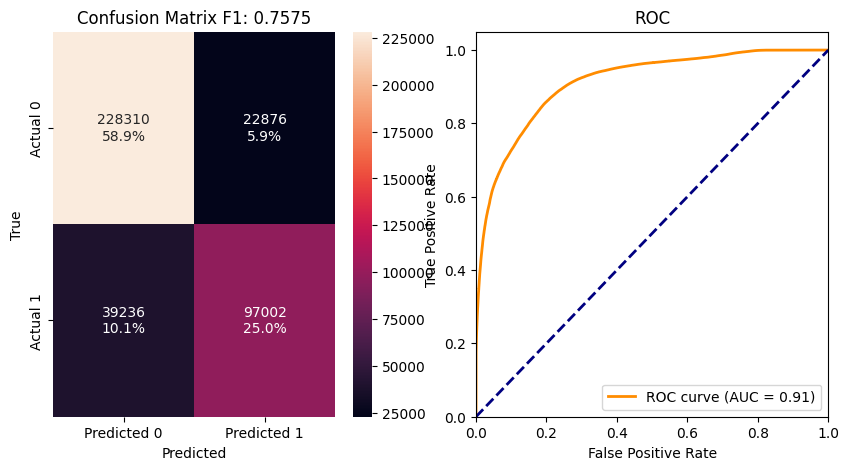

In [20]:
weights, config = torch.load('../best_model-3binary.pth')
# weights, config = torch.load('../best_model-lstm-83t_32-timerep.pth')
# config = json.load(open('../logs/search256/34/config.json'))
# weights = torch.load('../logs/search256/34/best_model.pth')
model = LSTMNet(config).to(device)
model.load_state_dict(weights)
evaluate(model, valloader, trainloader)

In [52]:
class IMUDatasetSimple(Dataset):
    def __init__(self, df, winsize=250, stride=50, transform=None, aug=False):
        self.X = torch.from_numpy(df[['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values)
        self.y = torch.from_numpy(df['rir'].values).to(torch.float32)
        if transform is not None:
            self.X = transform(self.X)
        self.X = self.X.transpose(0, 1).to(torch.float32)
        self.winsize = winsize
        self.stride = stride
        self.aug = aug

        self.len = (self.X.shape[1] - winsize) // stride + 1
        # pad to get at least one window
        if self.len <= 0:
            pad = winsize - self.X.shape[1]
            self.X = torch.cat([self.X, torch.zeros(self.X.shape[0], pad)], dim=1)
            self.y = torch.cat([self.y, torch.zeros(pad)])

        # pad by winsize // 2 to get more windows
        pad = (winsize // 2)
        self.X = torch.cat([self.X, torch.zeros(self.X.shape[0], pad)], dim=1)
        self.y = torch.cat([self.y, torch.zeros(pad)])

        self.len = (self.X.shape[1] - winsize) // stride + 1
    def __len__(self):
        return self.len
    def __getitem__(self, i):
        if i >= self.len:
            raise IndexError
        start = i * self.stride
        end = start + self.winsize
        y = self.y[start:end]#.mean()

        # FOR REGRESSION: y = y.mean() (single value)
        # y = y.mean()

        # FOR BINARY: 1 if y is last rep (< 0.5), 0 if not (single value)
        y = torch.Tensor([1.0 if y.mean() < 2.5 else 0.0])

        # FOR SEGMENTATION: if y changes during window, y = 1 at that point. everywhere else is 0 (<winsize> values)
        # y = segment_y(y)

        # FOR SEGMENTATION REGRESSION: y = time when y changes (single value)
        # diff = torch.diff(y)
        # y = torch.diff(y).argmin().unsqueeze(0) / self.winsize if diff.min() < 0 else torch.Tensor([-1])
        
        X = self.X[:, start:end]
        X = moving_average(X)
        if self.aug:
            X,y = warp_time(X, y)
            X = scale(X)
        return X, y

In [53]:
def evaluate_real_time(session_id, interval=64):
    session = df[df['session_id'] == session_id]
    print(session.shape)
    session_dataset = IMUDatasetSimple(session, winsize, interval, transform=None, aug=False)

    confs = []
    ys = []
    ypreds = []
    running_context = []

    with torch.no_grad():
        for X,y in session_dataset:
            X = X.unsqueeze(0).to(device)
            running_context.append(X.unsqueeze(0))
            if len(running_context) > n_LSTM_windows:
                running_context.pop(0)
            X = torch.cat(running_context, dim=1)
            conf = model(X).cpu()
            conf = F.sigmoid(conf[:,-1, 0])
            confs.append(conf)
            ypreds.append(conf.round())
            ys.append(y.cpu())
    ypreds = torch.cat(ypreds).flatten()
    ys = torch.cat(ys).flatten()
    confs = torch.cat(confs).flatten()

    cm = confusion_matrix(ys, ypreds, normalize='pred')

    precision, recall, f1, _ = precision_recall_fscore_support(ys, ypreds, average='binary')
    accuracy = (ypreds == ys).sum() / len(ys)

    return ypreds, ys, confs, precision, recall, f1, accuracy, cm

(2838, 12)
Precision: 0.7857, Recall: 1.0000, F1: 0.8800, Accuracy: 0.8605
ROC AUC: 0.9756


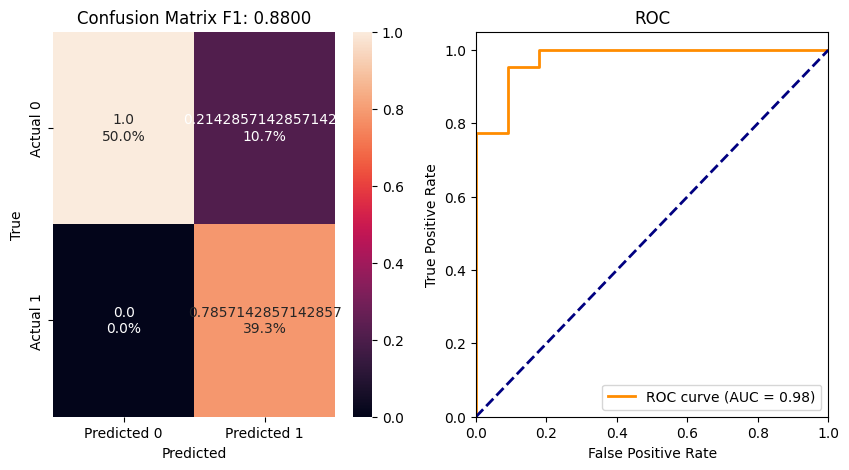

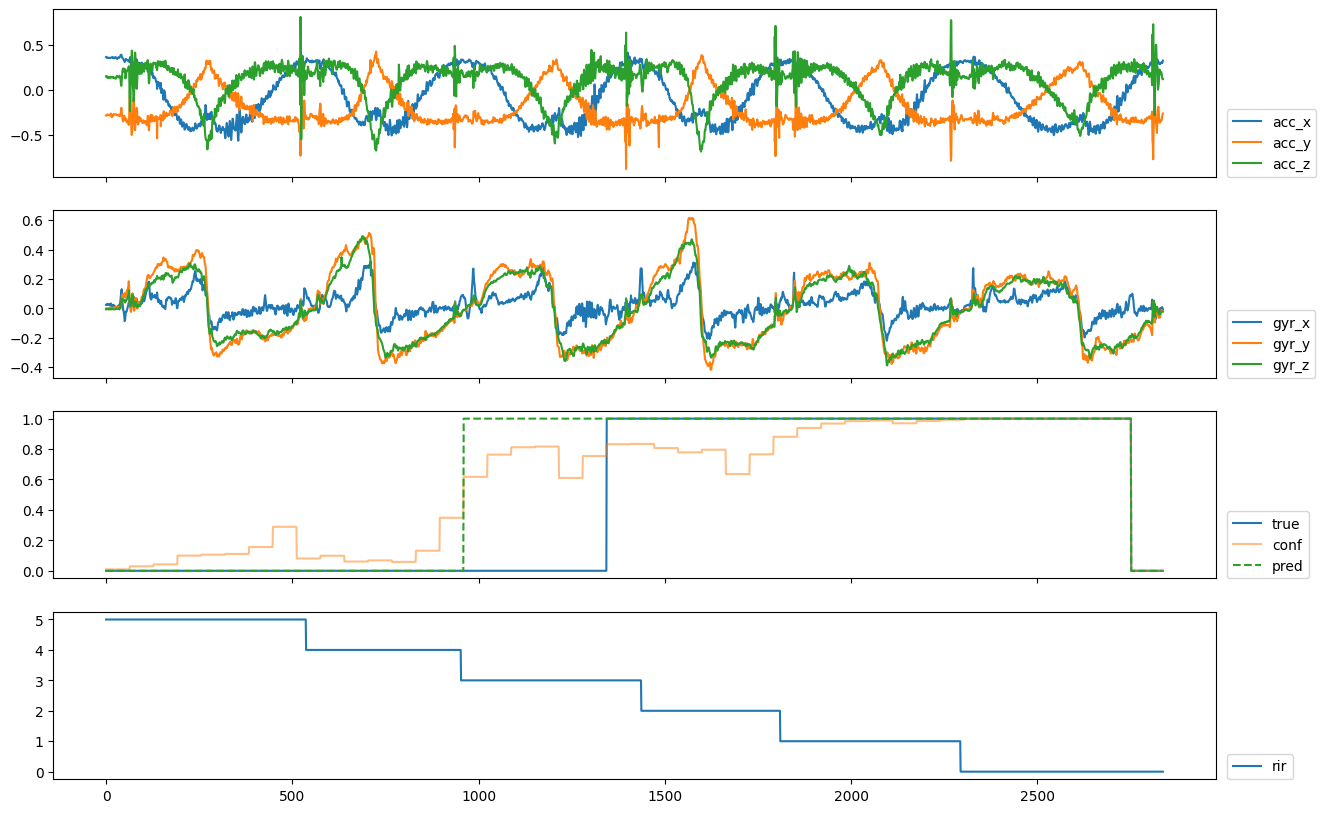

In [55]:
session_id = val_ids[1]

session = df[df['session_id'] == session_id]
session_dataset = IMUDatasetSimple(session, winsize, LSTM_stride, transform=None, aug=False)
interval = LSTM_stride
ypreds, ys, confs, precision, recall, f1, accuracy, cm = evaluate_real_time(session_id, interval=LSTM_stride)

tn, fp, fn, tp = cm.flatten()
total = tn + fp + fn + tp

labels = np.array([
    [f"{tn}\n{tn/total:.1%}", f"{fp}\n{fp/total:.1%}"],
    [f"{fn}\n{fn/total:.1%}", f"{tp}\n{tp/total:.1%}"]
])

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Accuracy: {accuracy:.4f}")

ypreds = torch.cat([
    torch.repeat_interleave(ypreds, interval),
    torch.zeros(session.shape[0] - (len(session_dataset) * interval))
])
ys = torch.cat([
    torch.repeat_interleave(ys, interval),
    torch.zeros(session.shape[0] - (len(session_dataset) * interval))
])
confs = torch.cat([
    torch.repeat_interleave(confs, interval),
    torch.zeros(session.shape[0] - (len(session_dataset) * interval))
])

fig, axes = plt.subplots(1,2,figsize=(10, 5))
sns.heatmap(cm, annot=labels, fmt='', xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix F1: {f1:.4f}')

fpr, tpr, thresholds = roc_curve(ys, confs)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal (random classifier)

# Formatting
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC')
axes[1].legend(loc="lower right")

fig, axes = plt.subplots(4,1, sharex=True, figsize=(15,10))
axes[0].plot(session['acc_x'].values, label='acc_x')
axes[0].plot(session['acc_y'].values, label='acc_y')
axes[0].plot(session['acc_z'].values, label='acc_z')
axes[1].plot(session['gyr_x'].values, label='gyr_x')
axes[1].plot(session['gyr_y'].values, label='gyr_y')
axes[1].plot(session['gyr_z'].values, label='gyr_z')
axes[2].plot(ys, label='true')
axes[2].plot(confs, label='conf', alpha=0.5)
axes[2].plot(ypreds, label='pred', linestyle='--')
axes[3].plot(session['rir'].values, label='rir')
axes[0].legend(loc=(1.01, 0))
axes[1].legend(loc=(1.01, 0))
axes[2].legend(loc=(1.01, 0))
axes[3].legend(loc=(1.01, 0))

In [56]:
precision, recall, f1, acc = [], [], [], []
for val_id in val_ids:
    ypreds, ys, confs, precisioni, recalli, f1i, acci, cm = evaluate_real_time(val_id, interval=LSTM_stride)
    precision.append(precisioni)
    recall.append(recalli)
    f1.append(f1i)
    acc.append(acci)
    print(f"Session {val_id}: Precision: {precisioni:.4f}, Recall: {recalli:.4f}, F1: {f1i:.4f}, Accuracy: {acci:.4f}")

precision = np.mean(precision)
recall = np.mean(recall)
f1 = np.mean(f1)
acc = np.mean(acc)
print(f"Mean Precision: {precision:.4f}, Mean Recall: {recall:.4f}, Mean F1: {f1:.4f}, Mean Accuracy: {acc:.4f}")

(2107, 12)
Session 4: Precision: 1.0000, Recall: 0.9167, F1: 0.9565, Accuracy: 0.9677
(2838, 12)
Session 62: Precision: 0.7857, Recall: 1.0000, F1: 0.8800, Accuracy: 0.8605
(2647, 12)
Session 18: Precision: 1.0000, Recall: 0.4667, F1: 0.6364, Accuracy: 0.8000
(2563, 12)
Session 0: Precision: 0.8667, Recall: 1.0000, F1: 0.9286, Accuracy: 0.9487
(2650, 12)
Session 28: Precision: 1.0000, Recall: 0.3182, F1: 0.4828, Accuracy: 0.6250
(3175, 12)
Session 50: Precision: 0.4545, Recall: 1.0000, F1: 0.6250, Accuracy: 0.6250
(6563, 12)
Session 10: Precision: 1.0000, Recall: 0.9737, F1: 0.9867, Accuracy: 0.9901
(5018, 12)
Session 34: Precision: 1.0000, Recall: 0.8158, F1: 0.8986, Accuracy: 0.9091
(6753, 12)
Session 12: Precision: 0.6190, Recall: 1.0000, F1: 0.7647, Accuracy: 0.8462
(2039, 12)
Session 54: Precision: 0.8462, Recall: 1.0000, F1: 0.9167, Accuracy: 0.9333
(4795, 12)
Session 47: Precision: 0.9524, Recall: 1.0000, F1: 0.9756, Accuracy: 0.9863
(2080, 12)
Session 31: Precision: 0.8333, Rec